# Notebook 2 — Baseline Clustering Analysis

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

Applies traditional clustering methods to the MICE-imputed dataset as a baseline:
- K-Means (k = 2–6)
- Gaussian Mixture Model (GMM, k = 2–6)

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

RESULTS_DIR = '../results'
IMPUTED_DIR = '../data/imputed_csv'
FIGURES_DIR = '../report template/Figures'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load EDA outputs and MICE-imputed data
with open(os.path.join(RESULTS_DIR, 'eda_output.pkl'), 'rb') as f:
    eda = pickle.load(f)

ELIGIBLE_VARS = eda['ELIGIBLE_VARS']
DOMAINS = eda['DOMAINS']

X_mice = pd.read_csv(os.path.join(IMPUTED_DIR, 'Imputed_MICE.csv'), index_col=0)
print(f'MICE data shape: {X_mice.shape}')

# Standardise for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mice[ELIGIBLE_VARS])
print(f'Scaled data shape: {X_scaled.shape}')

MICE data shape: (22075, 15)
Scaled data shape: (22075, 15)


## K-Means Clustering

In [3]:
k_range = range(2, 7)
kmeans_results = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    inertia = km.inertia_
    
    kmeans_results.append({
        'k': k,
        'Silhouette': round(sil, 4),
        'Inertia': round(inertia, 2),
        'labels': labels
    })
    print(f'K-Means k={k}: Silhouette={sil:.4f}, Inertia={inertia:.0f}')

kmeans_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'labels'} for r in kmeans_results])
print('\n', kmeans_df.to_string(index=False))

K-Means k=2: Silhouette=0.4127, Inertia=251503


K-Means k=3: Silhouette=0.1959, Inertia=210977


K-Means k=4: Silhouette=0.2019, Inertia=192635


K-Means k=5: Silhouette=0.1430, Inertia=178718


K-Means k=6: Silhouette=0.1397, Inertia=170638

  k  Silhouette   Inertia
 2      0.4127 251503.00
 3      0.1959 210977.18
 4      0.2019 192635.05
 5      0.1430 178718.39
 6      0.1397 170638.17


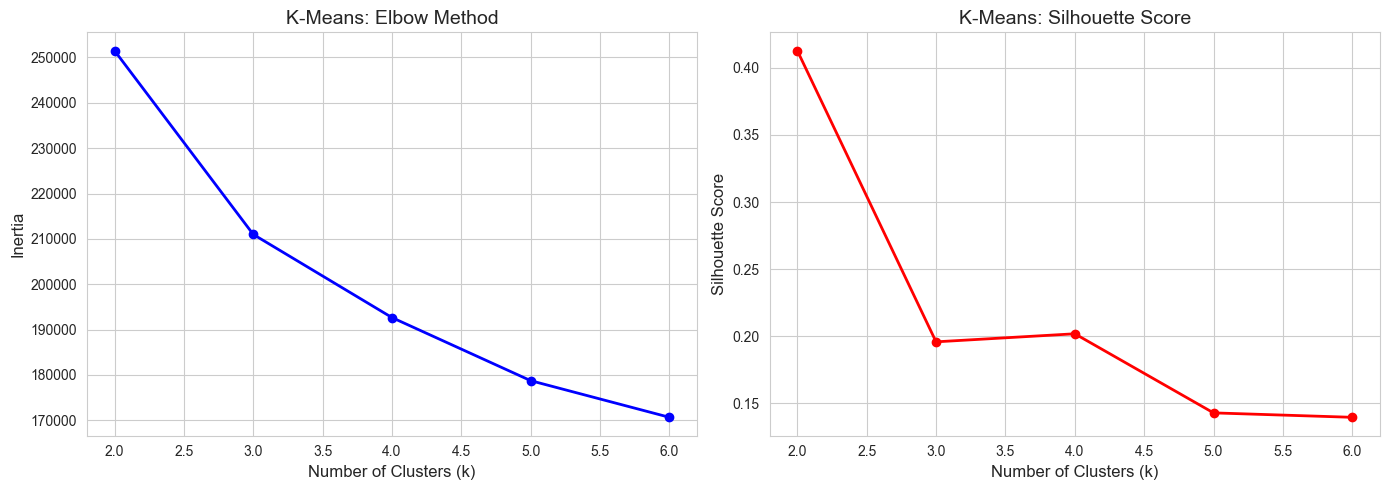

In [4]:
# K-Means elbow plot and silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), [r['Inertia'] for r in kmeans_results], 'bo-', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('K-Means: Elbow Method', fontsize=14)

ax2.plot(list(k_range), [r['Silhouette'] for r in kmeans_results], 'ro-', linewidth=2)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('K-Means: Silhouette Score', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'kmeans_elbow_silhouette.png'), dpi=300, bbox_inches='tight')
plt.show()

## Gaussian Mixture Model (GMM)

In [5]:
gmm_results = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=5, max_iter=200)
    labels = gmm.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    
    gmm_results.append({
        'k': k,
        'Silhouette': round(sil, 4),
        'BIC': round(bic, 2),
        'AIC': round(aic, 2),
        'labels': labels
    })
    print(f'GMM k={k}: Silhouette={sil:.4f}, BIC={bic:.0f}, AIC={aic:.0f}')

gmm_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'labels'} for r in gmm_results])
print('\n', gmm_df.to_string(index=False))

GMM k=2: Silhouette=0.1169, BIC=303756, AIC=301587


GMM k=3: Silhouette=0.0181, BIC=247868, AIC=244611


GMM k=4: Silhouette=-0.0185, BIC=198331, AIC=193986


GMM k=5: Silhouette=-0.0154, BIC=197100, AIC=191666


GMM k=6: Silhouette=-0.0318, BIC=7236, AIC=714

  k  Silhouette       BIC       AIC
 2      0.1169 303755.51 301586.92
 3      0.0181 247867.50 244610.61
 4     -0.0185 198330.96 193985.77
 5     -0.0154 197099.81 191666.32
 6     -0.0318   7235.97    714.17


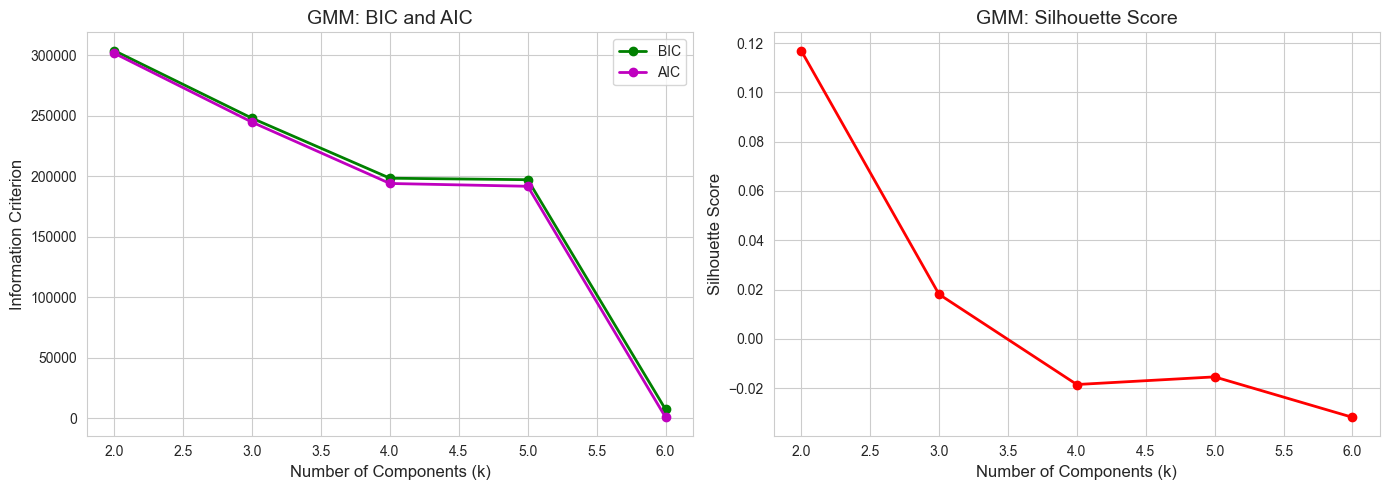

In [6]:
# GMM BIC/AIC plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), [r['BIC'] for r in gmm_results], 'go-', linewidth=2, label='BIC')
ax1.plot(list(k_range), [r['AIC'] for r in gmm_results], 'mo-', linewidth=2, label='AIC')
ax1.set_xlabel('Number of Components (k)', fontsize=12)
ax1.set_ylabel('Information Criterion', fontsize=12)
ax1.set_title('GMM: BIC and AIC', fontsize=14)
ax1.legend()

ax2.plot(list(k_range), [r['Silhouette'] for r in gmm_results], 'ro-', linewidth=2)
ax2.set_xlabel('Number of Components (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('GMM: Silhouette Score', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'gmm_bic_silhouette.png'), dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Save baseline results
baseline_results = {
    'kmeans_results': kmeans_results,
    'gmm_results': gmm_results
}
with open(os.path.join(RESULTS_DIR, 'baseline_clustering.pkl'), 'wb') as f:
    pickle.dump(baseline_results, f, protocol=4)

print('\n=== Notebook 2 Complete ===')


=== Notebook 2 Complete ===
